# Prequisite (cukup jalankan sekali)


In [ ]:
import nltk

# nltk.download('stopwords')
# nltk.download('words')
# nltk.download('wordnet')
# nltk.download('averaged_perceptron_tagger')
# nltk.download('averaged_perceptron_tagger_eng')

# Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import seaborn as sns

import emoji
from wordcloud import WordCloud
import nltk

from collections import Counter
import math

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.feature_selection import chi2, SelectPercentile
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

from text_preprocessing import preprocess_pipeline
from sklearn.pipeline import Pipeline
import pickle

import re
from nltk.corpus import stopwords
from nltk.corpus import words as nltk_words
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet


c:\Users\isalo\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


# Data Preview

In [ ]:
import pandas as pd
df = pd.read_parquet('train.parquet')
df.head()

,text,label
0,hey I am looking for Xray baggage datasets can...,not_spam
1,"""Get rich quick! Make millions in just days wi...",spam
2,URGENT MESSAGE: YOU WON'T BELIEVE WHAT WE HAVE...,spam
3,[Google AI Blog: Contributing Data to Deepfake...,not_spam
4,Trying to see if anyone already has timestamps...,not_spam


In [33]:
df.head().to_csv('df_head.csv', index=False)

In [ ]:
df[].shape

(8175, 2)

In [4]:
df.isnull().sum()

text     0
label    0
dtype: int64

In [101]:
!pip install --upgrade scikit-learn

  Obtaining dependency information for scikit-learn from https://files.pythonhosted.org/packages/89/3c/45c352094cfa60050bcbb967b1faf246b22e93cb459f2f907b600f2ceda5/scikit_learn-1.8.0-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency information for joblib>=1.3.0 from https://files.pythonhosted.org/packages/7b/91/984aca2ec129e2757d1e4e3c81c3fcda9d0f85b74670a094cc443d9ee949/joblib-1.5.3-py3-none-any.whl.metadata
  Obtaining dependency information for threadpoolctl>=3.2.0 from https://files.pythonhosted.org/packages/32/d5/f9a850d79b0851d1d4ef6456097579a9005b31fea68726a4ae5f2d82ddd9/threadpoolctl-3.6.0-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.1/8.1 MB 3.2 MB/s eta 0:00:03
   ---------------------------------------- 0.1/8.1 MB 1.3 MB/s eta 0:00:07
   - -------------------------------------- 0.2/8.1 MB 2.3 MB/s eta 0:00:04
   - -------------------------------------- 0.3/8.1 MB 2.0 MB/s

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pandas-profiling 3.2.0 requires joblib~=1.1.0, but you have joblib 1.5.3 which is incompatible.


In [102]:
import sklearn
print(sklearn.__version__)

1.3.0


In [5]:
print("Rata-rata panjang kata:", round(df['text'].apply(len).mean()))
print("Panjang maksimum kata:", df['text'].apply(len).max())
print("Panjang minimum kata:", df['text'].apply(len).min())


Rata-rata panjang kata: 369
Panjang maksimum kata: 41544
Panjang minimum kata: 2


In [6]:
df['label'].value_counts()

label
spam        4125
not_spam    4050
Name: count, dtype: int64

In [5]:
all_text = " ".join(df['text'].astype(str))
tokens = all_text.split()

word_counts = Counter(tokens)
print(f"Total kata: {len(word_counts)}")

Total kata: 47144


47144

# Phase

# EDA

### Distribusi noise

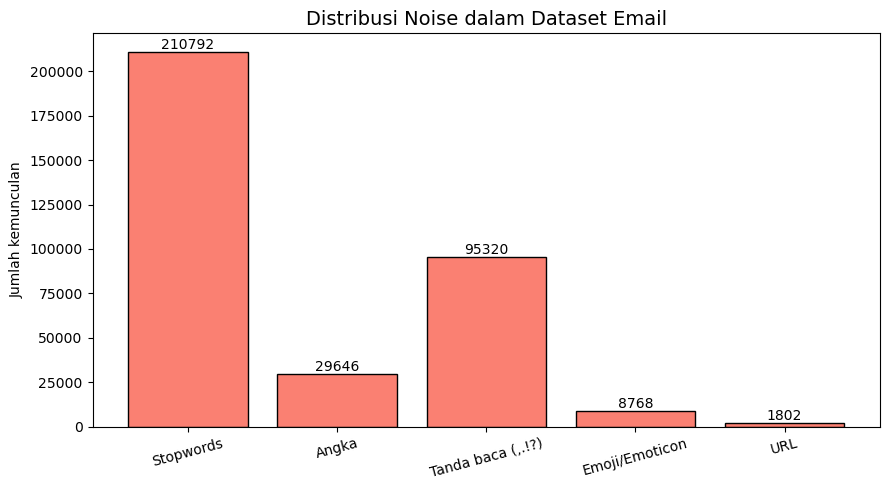

In [4]:
# Extract all words from dataset
all_words = ' '.join(df['text'].tolist())
stopword_en = set(stopwords.words('english'))

# Dictionary of noise count
noise = {
    'Stopwords': sum(all_words.lower().split().count(w) for w in stopword_en),
    'Angka': len(re.findall(r'\d', all_words)),
    'Tanda baca (,.!?)': len(re.findall(r'[,\.!?;:\"\']', all_words)),
    'Emoji/Emoticon': len(re.findall(r'[:;=]-?[\)\(\|DPp]|[\U0001F300-\U0001FFFF]', all_words)),
    'URL': len(re.findall(r'http\S+|www\S+', all_words)),
}

# Plot styling
plt.figure(figsize=(9, 5))
bars = plt.bar(noise.keys(), noise.values(), color='salmon', edgecolor='black')
plt.bar_label(bars)
plt.title('Distribusi Noise dalam Dataset Email', fontsize=14)
plt.ylabel('Jumlah kemunculan')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


### Macam Emoji

In [5]:
print(re.findall(r'[:;=]-?[\)\(\|DPp]|[\U0001F300-\U0001FFFF]', all_words))

['👋', '👋', '👋', '😴', '😒', '🌶', '🌶', '🌶', '💪', '🏃', '🥦', '💪', '💪', '💪', '🙌', '🙌', '🙌', '🤩', '🤩', '🤩', '👋', '💥', '🤳', '🤳', '💻', '🔥', '🚫', '🔥', '🔥', '🤑', '💰', '💰', ':)', '👀', '📣', '📈', '🚀', '🤑', '👉', '💕', '💬', '🔧', '🛠', '👍', '📝', '👥', '🤩', '🌸', '🌸', '🌸', '🤩', '🤩', '🤩', '😝', '😝', '😝', '🤯', '🤯', '🤯', ';D', '😩', ':)', ':-|', ':-|', ':-|', '🎉', '🎉', '🎉', ';)', '🚨', '🚨', '🦐', '🦐', '🍔', '🍔', '🍟', '🍟', '💥', '💥', '🎁', '🤯', '🔥', '💥', '👨', '🎤', '👩', '🎤', '🔞', '🦄', '🤑', '🤑', '🤑', '🏃', '🏃', '🏃', '🥑', '🎉', '🥳', '💥', '🤑', '💪', '👟', '🌴', '🌞', '👀', '💬', '🤑', '💰', '🔥', '🔥', '🔥', '🔥', '🔥', '🔥', '🔥', '🔥', '👉', '🏼', '🤯', '🤯', '🚫', '👉', '🤑', '🎉', '👍', '🙌', '🚨', '🚨', '🚨', '🚨', '🚨', '🚨', '🔥', '🔥', '🔥', '🔥', '🔥', '🔥', '🎉', '🎉', '🎉', '🎉', '🎉', '🎉', '🤑', '🤑', '🤑', '🤑', '🤑', '🚨', '🚨', '🏋', '🏋', '💪', '💪', '📚', '🤑', '💰', '🤑', '💰', '🤑', '📣', '📣', '📣', '😎', '🚨', '🚨', '🎉', '🎉', '🎉', '🤡', '🐱', '😜', '😂', '👌', '🔥', '🔥', '🔥', '🤑', '🤑', '🤑', '🎉', '🎉', '🎉', '🥧', '🥧', '🥧', '💰', '💰', '💰', '=p', '=p', '=p', '👉', '👉', '👉', '🤑', '

### Preview bentuk asli noise

D:\Users\bsi80273\AppData\Local\Temp\ipykernel_17920\1528004515.py:66: UserWarning: Glyph 128313 (\N{SMALL BLUE DIAMOND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128313 (\N{SMALL BLUE DIAMOND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


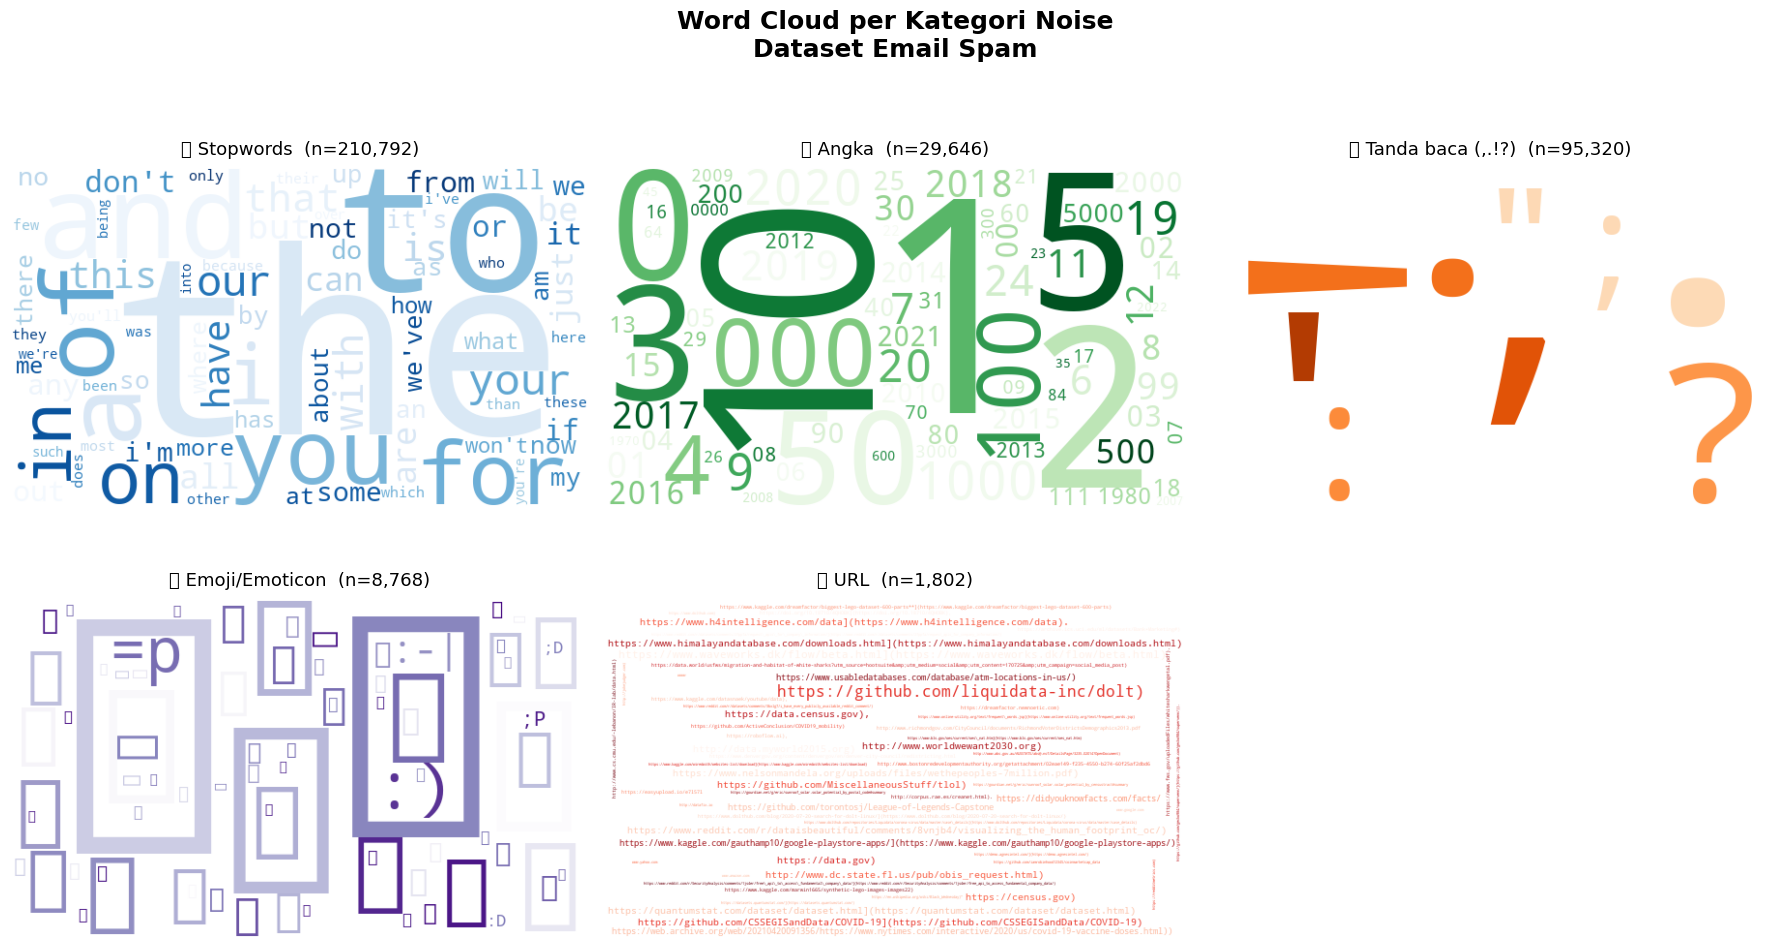

In [6]:
# Tokenisasi per kata
tokens = all_words.lower().split()

# Dictionary of noise frequency count
noise_freq = {
    'Stopwords': Counter(w for w in tokens if w in stopword_en),
    'Angka': Counter(re.findall(r'\b\d+\b', all_words)),
    'Tanda baca (,.!?)': Counter(re.findall(r'[,\.!?;:\"\']', all_words)),
    'Emoji/Emoticon': Counter(re.findall(r'[:;=]-?[\)\(\|DPp]|[\U0001F300-\U0001FFFF]', all_words)),
    'URL': Counter(re.findall(r'http\S+|www\S+', all_words)),
}

# Dictionary of colormap for each noise category
cmap_map = {
    'Stopwords': 'Blues',
    'Angka': 'Greens',
    'Tanda baca (,.!?)': 'Oranges',
    'Emoji/Emoticon': 'Purples',
    'URL': 'Reds',
}

# Function to generate Word Cloud
def make_wc(freq_dict: Counter[str, str], colormap: str, max_words=80):
    """
    Membuat Word Cloud dari frequency dictionary.
    """
    wc = WordCloud(
        width=600, height=350,
        background_color='white',
        colormap=colormap,
        max_words=max_words,
        collocations=False,
    )
    if freq_dict:
        wc.generate_from_frequencies(freq_dict)
    return wc

# Layouting
n = len(noise)
ncols = 3
nrows = -(-n // ncols)  


# Plotting Word Cloud
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 6, nrows * 5))
fig.suptitle('Word Cloud per Kategori Noise\nDataset Email Spam',
             fontsize=18, fontweight='bold', y=1.01)

for ax, (label, freq) in zip(axes.flatten(), noise_freq.items()):
    cmap = cmap_map.get(label, 'cool')
    if freq:
        wc = make_wc(freq, cmap)
        ax.imshow(wc, interpolation='bilinear')
        ax.set_title(f'🔹 {label}  (n={noise[label]:,})', fontsize=13, pad=10)
    else:
        ax.text(0.5, 0.5, 'Tidak ditemukan',
                ha='center', va='center', fontsize=13, color='gray',
                transform=ax.transAxes)
        ax.set_title(f'🔹 {label}', fontsize=13, pad=10)
    ax.axis('off')

# Sembunyikan ax kosong
for ax in axes.flatten()[n:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

### Cek kata terpanjang, terpendek, dan null

In [7]:
df['text_length'] = df['text'].apply(len) # Tambah kolom panjang kata

<Axes: >

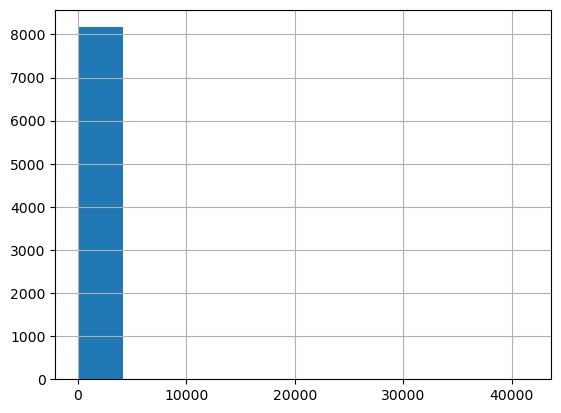

In [8]:
df['text_length'].hist()

In [17]:
counts, bins = np.histogram(df['text_length'], bins=150)

# bikin dataframe histogram
hist_df = pd.DataFrame({
    'bin_start': bins[:-1],
    'bin_end': bins[1:],
    'count': counts
})

hist_df.head()

,bin_start,bin_end,count
0,2.000000,278.946667,4017
1,278.946667,555.893333,2640
2,555.893333,832.840000,1184
3,832.840000,1109.786667,147
4,1109.786667,1386.733333,93


In [9]:
hist_df.to_csv('histogram_text_length.csv', index=False)

In [12]:
df[['text_length']].describe()

,text_length
count,8175.000000
mean,369.111315
std,565.820388
min,2.000000
25%,175.000000
50%,284.000000
75%,507.000000
max,41544.000000


In [10]:
df[df['text_length'] == 41544].to_csv('kata_terpanjang.csv', index=False) # Cek kata terpanjang

In [10]:
df[df['text_length'] == 0] # Cek kata null

,text,label,text_length,mask_text,text_normalized,lemma


In [11]:
df[df['text_length'] < 10] # Cek kata terpendek (kurang dari 10 character)

,text,label,text_length,mask_text,text_normalized,lemma
1569,^^,not_spam,2,^^,,
2949,See title,not_spam,9,See title,see title,see title
3142,TIA :),not_spam,6,TIA :),tia,tia
3687,Title.,not_spam,6,Title.,title,title
3987,Thanks!,not_spam,7,Thanks!,thanks,thanks
5765,question,not_spam,8,question,question,question
7788,Thanks,not_spam,6,Thanks,thanks,thanks


### Spam vs Non Spam

In [35]:
def extract_noise(text):
    stopword_en = set(stopwords.words('english'))
    words = text.lower().split()

    return pd.Series({
        'stopwords': sum(w in stopword_en for w in words),

        'angka': len(re.findall(r'\d', text)),

        'tanda_baca': len(
            re.findall(r'[,\.!?;:\"\']', text)
        ),

        'emoji': len(
            re.findall(
                r'[:;=]-?[\)\(\|DPp]|[\U0001F300-\U0001FFFF]',
                text
            )
        ),

        'url': len(
            re.findall(r'http\S+|www\S+', text)
        )
    })

# =========================
# tambah kolom
# =========================
df_corr = df.copy()
df_corr[
    ['stopwords',
     'angka',
     'tanda_baca',
     'emoji',
     'url']
] = df_corr['text'].apply(extract_noise)

df_corr['label'] = df_corr['label'].map({'spam': 1, "not_spam": 0})
df_corr.head()

,text,label,text_length,stopwords,angka,tanda_baca,emoji,url
0,hey I am looking for Xray baggage datasets can...,0,76,9,0,0,0,0
1,"""Get rich quick! Make millions in just days wi...",1,129,9,0,6,0,0
2,URGENT MESSAGE: YOU WON'T BELIEVE WHAT WE HAVE...,1,495,46,0,24,0,0
3,[Google AI Blog: Contributing Data to Deepfake...,0,1057,35,16,41,0,7
4,Trying to see if anyone already has timestamps...,0,223,19,0,6,0,0


<Axes: >

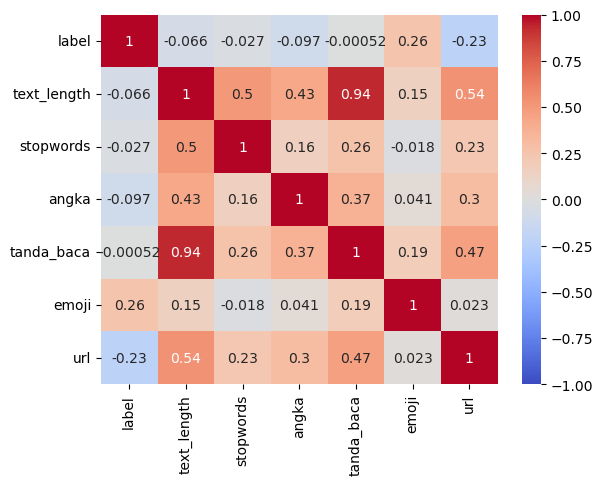

In [ ]:
sns.heatmap(df_corr.select_dtypes(include='number').corr(), annot=True,
            vmin=-1, vmax=1, cmap='coolwarm')

# Masking

In [4]:
def mask_urls(text:str):
    """
    Ganti URL shortener (bit.ly, tinyurl, dst.) → 'shorturltoken'
    dan URL biasa + naked domain → 'urltoken'.
    """
    # Bedakan URL suspicious vs normal
    suspicious_patterns = r'(bit\.ly|tinyurl|goo\.gl|t\.co|shorturl)'
    
    # URL shortener → token khusus
    text = re.sub(
        rf'https?://\S*{suspicious_patterns}\S*', 
        ' shorturltoken ', text, flags=re.IGNORECASE
    )
    
    # URL biasa
    text = re.sub(
        r'https?://\S+', 
        ' urltoken ', text
    )
    
    # Naked domain (tanpa http)
    text = re.sub(
        r'\b(?:www\.)\S+\.\S+', 
        ' urltoken ', text
    )
    
    return text

df['mask_text'] = df['text'].apply(mask_urls)

In [5]:
def mask_currency(text:str):
    """
    Ganti nominal Rp/IDR → 'nominaltoken',
    nominal USD/$  → 'nominaltoken',
    angka besar standalone (≥4 digit) → 'numbertoken'.
    """
    # Format Rp / IDR
    text = re.sub(
        r'Rp\.?\s?[\d.,]+(?:\s?(?:ribu|juta|miliar|rb|jt|M))?',
        ' nominaltoken ', text, flags=re.IGNORECASE
    )
    
    # Format USD / simbol $
    text = re.sub(
        r'\$\s?[\d.,]+(?:\s?(?:thousand|million|billion))?',
        ' nominaltoken ', text, flags=re.IGNORECASE
    )
    
    # Angka besar standalone (>= 4 digit) — hati-hati jangan overmask
    text = re.sub(
        r'\b\d{4,}(?:[.,]\d+)*\b',
        ' numbertoken ', text
    )
    
    return text

df['mask_text'] = df['mask_text'].apply(mask_currency)

In [ ]:
def normalize_elongation(text:str, max_repeat = 2):
    """
    Normalisasi karakter yang diulang berlebihan.
    
    Contoh:
        fireeee   → fire
        gratiisss → gratiss  (max_repeat=2, biar tetap bisa bedain 'free' vs 'freee')
        wooow     → woow
        hahaha    → hahaha (tidak terpengaruh, beda pola)
    """
    
    # Ganti karakter yang muncul > max_repeat kali berturut-turut
    pattern = rf'(.)\1{{{max_repeat},}}'
    return re.sub(pattern, r'\1' * max_repeat, text)

df['mask_text'] = df['mask_text'].apply(normalize_elongation)


In [51]:
df[['mask_text','text']]

,mask_text,text
0,hey I am looking for Xray baggage datasets can...,hey I am looking for Xray baggage datasets can...
1,"""Get rich quick! Make millions in just days wi...","""Get rich quick! Make millions in just days wi..."
2,URGENT MESSAGE: YOU WON'T BELIEVE WHAT WE HAVE...,URGENT MESSAGE: YOU WON'T BELIEVE WHAT WE HAVE...
3,[Google AI Blog: Contributing Data to Deepfake...,[Google AI Blog: Contributing Data to Deepfake...
4,Trying to see if anyone already has timestamps...,Trying to see if anyone already has timestamps...
...,...,...
8170,"Hi all,\n\nWe create datasets by taking pictur...","Hi all,\n\nWe create datasets by taking pictur..."
8171,DEALS! DEALS! DEALS!\n\nHey peeps! You won't b...,DEALS! DEALS! DEALS!\n\nHey peeps! You won't b...
8172,Hi\n\nI am working on a project and need penal...,Hi\n\nI am working on a project and need penal...
8173,Do you want to BLOW UP your social media follo...,Do you want to BLOW UP your social media follo...


## Casefolding and Normalization

In [ ]:
english_words = set(nltk_words.words())

def normalize_elongation_smart(text):
    """
    Normalisasi karakter yang diulang berlebihan, dengan melihat kamus inggris.
    
    Contoh:
        fireeee   → fire
        gratiisss → gratiss  (max_repeat=2, biar tetap bisa bedain 'free' vs 'freee')
        wooow     → woow
        hahaha    → hahaha (tidak terpengaruh, beda pola)
    """
    def fix_word(word):
        # Kurangi dulu ke max_repeat=2
        reduced = re.sub(r'(.)\1{2,}', r'\1\1', word)
        
        # Coba kurangi sampai ketemu di dictionary
        for n in range(len(reduced), 0, -1):
            candidate = re.sub(r'(.)\1+', lambda m: m.group(1) * min(len(m.group()), n), reduced)
            if candidate.lower() in english_words:
                return candidate
        
        return reduced  
    
    return ' '.join(fix_word(w) for w in text.split())


df['text_normalized'] = df['mask_text'].apply(normalize_elongation)

# Remove enter (\n)
df['text_normalized'] = df['text_normalized'].apply(lambda x: re.sub('\\n',' ', x).strip())

# Remove Emoji
df['text_normalized'] = df['text_normalized'].apply(lambda x: re.sub(r'[:;=]-?[\)\(\|DPp]|[\U0001F300-\U0001FFFF]','', x).strip())

def remove_punctuation(text):
    """
    Hapus punctuation tapi JAGA token masking (urltoken, nominaltoken, dst)
    dan angka yang masih tersisa.
    
    Contoh:
        "Klik urltoken sekarang!!!"     → "Klik urltoken sekarang"
        "Gratis??? Hub. kami 08123..."  → "Gratis Hub kami 08123"
        "harga: Rp.10rb/hari"          → "harga Rp10rbari"  ← (sudah di-mask sebelumnya, nominaltoken hari)
    """
    # Hapus semua karakter selain huruf, angka, dan spasi
    text = re.sub(r'[^\w\s]', '', text)
    
    # Normalisasi spasi ganda hasil hapus punctuation
    text = re.sub(r'\s+', ' ', text)
    
    return text.strip()

df['text_normalized'] = df['text_normalized'].apply(remove_punctuation)

#Casefold menjadi lowercase
df['text_normalized'] = df['text_normalized'].str.lower()

#Remove 
df['text_normalized'] = df['text_normalized'].str.strip()

# Lemma

In [ ]:
lemmatizer = WordNetLemmatizer()
MASK_TOKENS = {'urltoken', 'shorturltoken', 'nominaltoken', 'numbertoken'}

def get_wordnet_pos(word:str):
    """
    Map POS tag dari NLTK ke format konstanta WordNet.

    Mengambil kata sebagai input, menentukan POS tag-nya menggunakan NLTK,
    lalu mengembalikan konstanta WordNet yang sesuai untuk digunakan
    dalam proses lemmatization.

    Parameters
    ----------
    word : str
        Kata tunggal yang ingin diketahui POS-nya.

    Returns
    -------
    str
        Konstanta WordNet: wordnet.ADJ, wordnet.VERB, wordnet.NOUN,
        atau wordnet.ADV. Default ke wordnet.NOUN jika tag tidak dikenali.

    Contoh
    --------
    >>> get_wordnet_pos("running")
    'v'  # wordnet.VERB
    >>> get_wordnet_pos("beautiful")
    'a'  # wordnet.ADJ
    >>> get_wordnet_pos("quickly")
    'r'  # wordnet.ADV
    >>> get_wordnet_pos("dog")
    'n'  # wordnet.NOUN
    >>> get_wordnet_pos("xyzabc")  # tag tidak dikenali → default NOUN
    'n'  # wordnet.NOUN
    """
    tag = nltk.pos_tag([word])[0][1][0].upper()
    tag_map = {
        'J': wordnet.ADJ,
        'V': wordnet.VERB,
        'N': wordnet.NOUN,
        'R': wordnet.ADV
    }
    return tag_map.get(tag, wordnet.NOUN) 

def apply_lemmatization(text:str):
    words = text.split()
    result = [
        word if word in MASK_TOKENS
        else lemmatizer.lemmatize(word, get_wordnet_pos(word))
        for word in words
    ]
    return ' '.join(result)

df['lemma'] = df['text_normalized'].apply(apply_lemmatization)

# Remove stoprword

In [14]:
MASK_TOKENS = {'urltoken', 'shorturltoken', 'nominaltoken', 'numbertoken'}
BASE_STOPWORDS = set(stopwords.words('english'))

def remove_stopwords(text):
    words = text.split()
    result = [
        word for word in words
        if word in MASK_TOKENS or word not in BASE_STOPWORDS
    ]
    return ' '.join(result)

df['text_remove_sw'] = df['lemma'].apply(remove_stopwords)

In [55]:
df[df['text_length'] == 2] 

,text,label,text_length,mask_text,text_normalized,lemma,text_remove_sw
1569,^^,not_spam,2,^^,,,


In [15]:
df = df[df['text_remove_sw'] != ''] #remove empty string


In [ ]:
df.to_csv('preprocessed.csv')

# EDA Setelah Preprocessing

In [57]:
def plot_20_word(all_words, title):
    """
    Plot top 20 words from a list of words.
    """
    counter = Counter(all_words)
    top20 = pd.DataFrame(counter.most_common(20), columns = ["word", "count"])
    
    fig, ax = plt.subplots(figsize = (12, 7))
    palette = sns.color_palette("flare", n_colors = 20)
    
    sns.barplot(
        data = top20,
        x = "count",
        y = "word",
        palette = palette,
        orient = "h",
        ax = ax,
        edgecolor = "white",
        linewidth = 0.5,
    )
    
    # Anotasi nilai di ujung bar
    for i, (val, word) in enumerate(zip(top20["count"], top20["word"])):
        ax.text(val + 0.2, i, str(val), va="center", fontsize=10, color="#333333", fontweight="bold")
    
    # Styling
    ax.set_title(title, fontsize = 15, fontweight = "bold", pad = 15, color = "#1a1a2e")
    ax.set_xlabel("Jumlah Kemunculan", fontsize = 12, color = "#444")
    ax.set_ylabel("Kata", fontsize = 12, color = "#444")
    ax.tick_params(axis = "y", labelsize = 11)
    ax.tick_params(axis = "x", labelsize = 10)
    ax.set_xlim(0, top20["count"].max() + 3)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis = "x", linestyle="--", alpha = 0.4, color = "gray")
    ax.set_facecolor("#fafafa")
    fig.patch.set_facecolor("#ffffff")
    
    plt.tight_layout()

### Distribusi kata untuk label = spam

D:\Users\bsi80273\AppData\Local\Temp\ipykernel_17920\1313602366.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


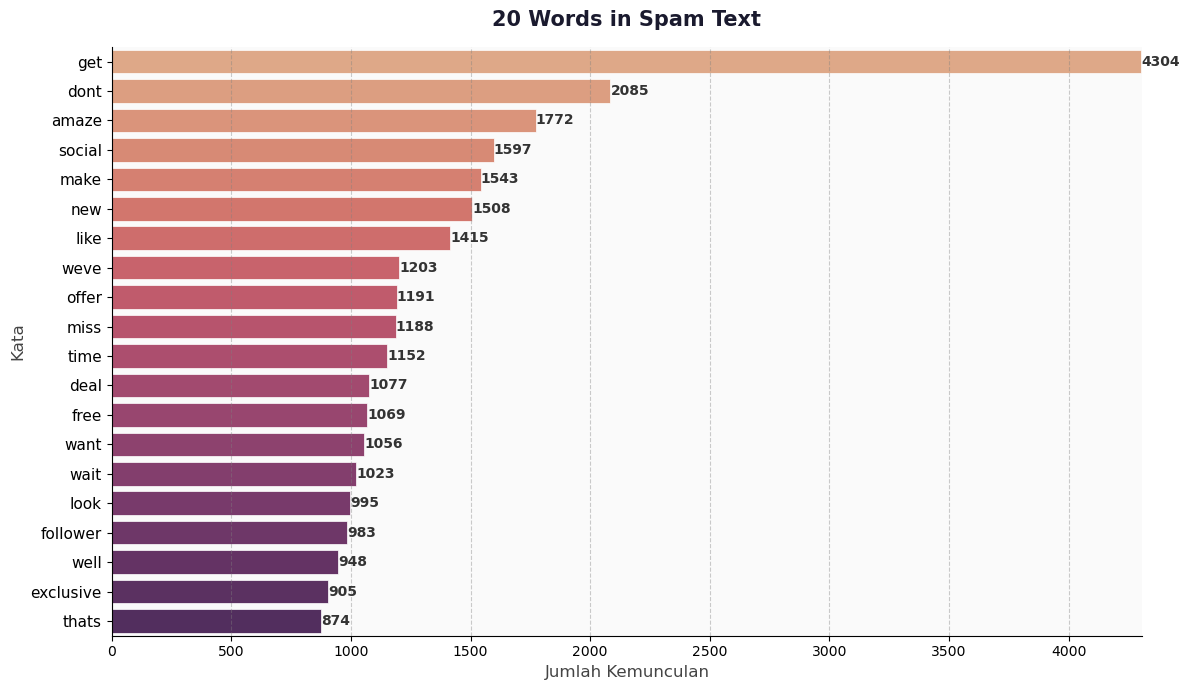

In [58]:
all_words = ' '.join(df[df['label'] == "spam"]['text_remove_sw']).split()
plot_20_word(all_words, title = "20 Words in Spam Text")



### Distribusi kata untuk label = not_spam

D:\Users\bsi80273\AppData\Local\Temp\ipykernel_17920\1313602366.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


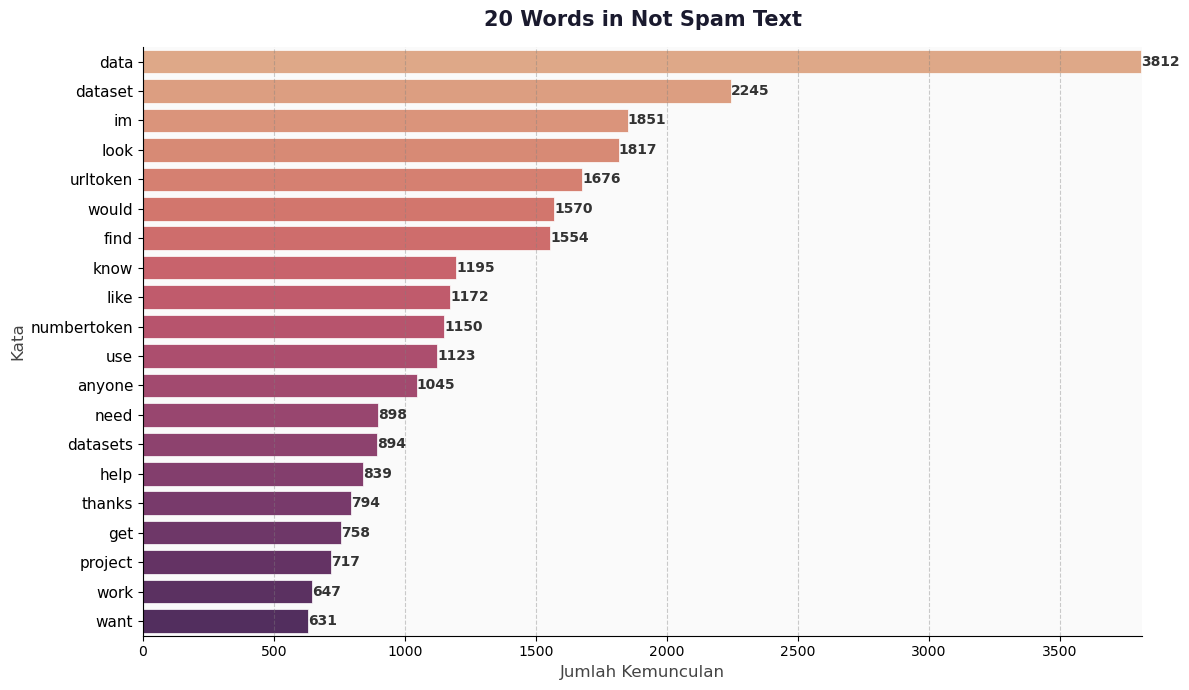

In [59]:
all_words = ' '.join(df[df['label'] == "not_spam"]['text_remove_sw']).split()
plot_20_word(all_words, title="20 Words in Not Spam Text")


# Label Encoding

In [22]:
df = pd.read_csv('preprocessed.csv')
df.head()

,Unnamed: 0,text,label,text_length,mask_text,text_normalized,lemma,text_remove_sw
0,0,hey I am looking for Xray baggage datasets can...,0,76,hey I am looking for Xray baggage datasets can...,hey i am looking for xray baggage datasets can...,hey i be look for xray baggage datasets can yo...,hey look xray baggage datasets provide
1,1,"""Get rich quick! Make millions in just days wi...",1,129,"""Get rich quick! Make millions in just days wi...",get rich quick make millions in just days with...,get rich quick make million in just day with o...,get rich quick make million day new revolution...
2,2,URGENT MESSAGE: YOU WON'T BELIEVE WHAT WE HAVE...,1,495,URGENT MESSAGE: YOU WON'T BELIEVE WHAT WE HAVE...,urgent message you wont believe what we have t...,urgent message you wont believe what we have t...,urgent message wont believe offer hey yeah eye...
3,3,[Google AI Blog: Contributing Data to Deepfake...,0,1057,[Google AI Blog: Contributing Data to Deepfake...,google ai blog contributing data to deepfake d...,google ai blog contribute data to deepfake det...,google ai blog contribute data deepfake detect...
4,4,Trying to see if anyone already has timestamps...,0,223,Trying to see if anyone already has timestamps...,trying to see if anyone already has timestamps...,try to see if anyone already have timestamps o...,try see anyone already timestamps key event ha...


In [20]:
df['label'] = df['label'].map({"spam" : 1, "not_spam" : 0})
df.head()

,Unnamed: 0,text,label,text_length,mask_text,text_normalized,lemma,text_remove_sw
0,0,hey I am looking for Xray baggage datasets can...,NaN,76,hey I am looking for Xray baggage datasets can...,hey i am looking for xray baggage datasets can...,hey i be look for xray baggage datasets can yo...,hey look xray baggage datasets provide
1,1,"""Get rich quick! Make millions in just days wi...",NaN,129,"""Get rich quick! Make millions in just days wi...",get rich quick make millions in just days with...,get rich quick make million in just day with o...,get rich quick make million day new revolution...
2,2,URGENT MESSAGE: YOU WON'T BELIEVE WHAT WE HAVE...,NaN,495,URGENT MESSAGE: YOU WON'T BELIEVE WHAT WE HAVE...,urgent message you wont believe what we have t...,urgent message you wont believe what we have t...,urgent message wont believe offer hey yeah eye...
3,3,[Google AI Blog: Contributing Data to Deepfake...,NaN,1057,[Google AI Blog: Contributing Data to Deepfake...,google ai blog contributing data to deepfake d...,google ai blog contribute data to deepfake det...,google ai blog contribute data deepfake detect...
4,4,Trying to see if anyone already has timestamps...,NaN,223,Trying to see if anyone already has timestamps...,trying to see if anyone already has timestamps...,try to see if anyone already have timestamps o...,try see anyone already timestamps key event ha...


# Split Data

In [23]:
X = df["text_remove_sw"]
y = df["label"]
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42, stratify = y
)

In [35]:
X_train.shape, X_test.shape

((6539,), (1635,))

# Features Encoding

In [39]:

tfidf = TfidfVectorizer(
    ngram_range = (1, 2), 
    sublinear_tf = True,
)
 
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)
 
print(f"\nShape matrix TF-IDF train : {X_train_tfidf.shape}")
print(f"Shape matrix TF-IDF test  : {X_test_tfidf.shape}")



Shape matrix TF-IDF train : (6539, 129591)
Shape matrix TF-IDF test  : (1635, 129591)


### Top Features

C:\Users\isalo\AppData\Local\Temp\ipykernel_18176\4022128957.py:56: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap(cmap_name)  # pakai parameter


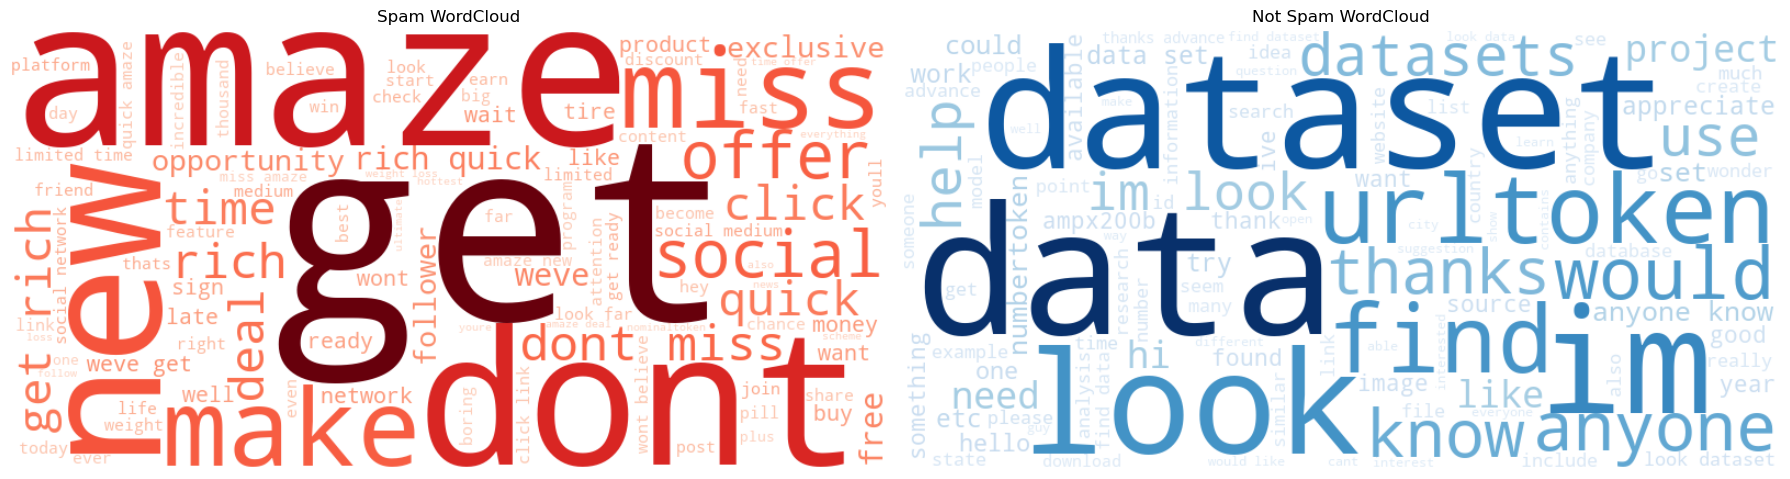

In [25]:

feature_names = tfidf.get_feature_names_out()

# spam
spam_mask = (y_train == 1).to_numpy()
X_spam = X_train_tfidf[spam_mask]
spam_scores = X_spam.mean(axis=0).A1

# not spam
ham_mask = (y_train == 0).to_numpy()
X_ham = X_train_tfidf[ham_mask]
ham_scores = X_ham.mean(axis=0).A1

# =========================
# DataFrame
# =========================

spam_df = pd.DataFrame({
    'feature': feature_names,
    'score': spam_scores
}).sort_values(by='score', ascending=False)

ham_df = pd.DataFrame({
    'feature': feature_names,
    'score': ham_scores
}).sort_values(by='score', ascending=False)

# =========================
# Ambil top feature
# =========================

top_n = 100

spam_words = dict(
    zip(
        spam_df['feature'].head(top_n),
        spam_df['score'].head(top_n)
    )
)

ham_words = dict(
    zip(
        ham_df['feature'].head(top_n),
        ham_df['score'].head(top_n)
    )
)

# =========================
# Color Function
# makin terang = score makin tinggi
# =========================

def make_color_func(freq_dict, cmap_name='autumn'):  # tambah parameter cmap_name

    max_score = max(freq_dict.values())
    norm = mcolors.Normalize(vmin=0, vmax=max_score)
    cmap = cm.get_cmap(cmap_name)  # pakai parameter

    def color_func(word, *args, **kwargs):
        score = freq_dict[word]
        rgba = cmap(norm(score))
        r, g, b, _ = rgba
        return f"rgb({int(r*255)}, {int(g*255)}, {int(b*255)})"

    return color_func


# =========================
# Wordcloud
# =========================

wc_spam = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate_from_frequencies(spam_words)

wc_spam.recolor(
    color_func=make_color_func(spam_words, cmap_name='Reds')
)

wc_ham = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate_from_frequencies(ham_words)

wc_ham.recolor(
    color_func=make_color_func(ham_words, cmap_name='Blues')
)

# =========================
# Plot Side by Side
# =========================

fig, ax = plt.subplots(1, 2, figsize=(18,8))

ax[0].imshow(wc_spam, interpolation='bilinear')
ax[0].set_title('Spam WordCloud')
ax[0].axis('off')

ax[1].imshow(wc_ham, interpolation='bilinear')
ax[1].set_title('Not Spam WordCloud')
ax[1].axis('off')

plt.tight_layout()
plt.show()

In [81]:
spam_df

,feature,score
47930,get,0.035997
5836,amaze,0.026902
33173,dont,0.025100
76734,new,0.020043
73099,miss,0.019903
...,...,...
62753,label measurement,0.000000
62752,label maybe,0.000000
62751,label many,0.000000
62750,label manually,0.000000


In [82]:
ham_df

,feature,score
26563,data,0.029998
27947,dataset,0.025425
55950,im,0.019861
67395,look,0.018628
119714,urltoken,0.018612
...,...,...
64772,life weve,0.000000
64773,life without,0.000000
64774,life wont,0.000000
64775,life world,0.000000


### Spam vs Non spam Vector

In [28]:
import numpy as np
import pandas as pd
import plotly.express as px

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.manifold import TSNE

# ======================
# TF-IDF
# ======================

tfidf = TfidfVectorizer(
    max_features=500,
    ngram_range=(1,2),
    min_df=2,
    sublinear_tf=True
)

X_tfidf = tfidf.fit_transform(df['text_remove_sw'])

words = np.array(tfidf.get_feature_names_out())

# ======================
# WORD LABELING
# ======================

spam_mean = np.asarray(
    X_tfidf[(df['label']==1).values].mean(axis=0)
).flatten()

ham_mean = np.asarray(
    X_tfidf[(df['label']==0).values].mean(axis=0)
).flatten()

word_class = np.where(
    spam_mean > ham_mean,
    'Spam Word',
    'Non Spam Word'
)

# ======================
# WORD VECTORS
# ======================

word_vectors = X_tfidf.T.toarray()

# ======================
# t-SNE 3D
# ======================

tsne = TSNE(
    n_components=3,
    perplexity=30,
    random_state=42,
    init='pca'
)

X_3d = tsne.fit_transform(word_vectors)

# ======================
# DATAFRAME
# ======================

plot_df = pd.DataFrame({
    'x': X_3d[:,0],
    'y': X_3d[:,1],
    'z': X_3d[:,2],
    'word': words,
    'class': word_class,
    'spam_score': spam_mean,
    'ham_score': ham_mean
})


plot_df

,x,y,z,word,class,spam_score,ham_score
0,84.377678,-21.849804,-17.519226,10,Spam Word,0.010047,0.004082
1,-18.006634,-5.228196,27.882135,100,Spam Word,0.004184,0.003716
2,35.387543,-26.603168,-54.433285,50,Spam Word,0.009053,0.002192
3,-71.177963,-41.225460,48.102741,able,Non Spam Word,0.002605,0.011351
4,0.740756,-35.478409,-44.506413,access,Spam Word,0.014146,0.007488
...,...,...,...,...,...,...,...
495,23.501743,-12.586362,42.926716,yo,Spam Word,0.006754,0.000106
496,60.161518,-22.001968,-25.237104,youll,Spam Word,0.025083,0.000289
497,11.554646,-18.371181,4.384956,youll get,Spam Word,0.006185,0.000000
498,20.705103,31.014757,54.088547,youre,Spam Word,0.015998,0.000690


In [29]:
plot_df.to_csv('vector_plot_df.csv', index=False)

In [27]:


# ======================
# PLOTLY
# ======================

fig = px.scatter_3d(
    plot_df,
    x='x',
    y='y',
    z='z',
    color='class',
    text='word',
    hover_data={
        'spam_score': True,
        'ham_score': True
    },
    color_discrete_map={
        'Spam Word': 'red',
        'Non Spam Word': 'blue'
    },
    title='3D Spam vs Non Spam Word Visualization'
)

fig.update_traces(
    marker=dict(size=4)
)

fig.show()

c:\Users\isalo\anaconda3\Lib\site-packages\plotly\express\_core.py:1979: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  sf: grouped.get_group(s if len(s) > 1 else s[0])


# Phase 1

H0: Kata yang memiliki nilai chi square diluar IQR TIDAK MENYEBABKAN overfitting
H1: Kata yang memiliki nilai chi square diluar IQR MENYEBABKAN overfitting


H₀: Model yang dilatih menggunakan seluruh fitur TF-IDF (tanpa seleksi fitur) memiliki performa yang sama atau lebih tinggi dibandingkan model yang dilatih menggunakan 20% fitur TF-IDF teratas berdasarkan skor chi-square.
H₁: Model yang dilatih menggunakan 20% fitur TF-IDF teratas (berdasarkan seleksi fitur chi-square) memiliki performa lebih tinggi dibandingkan model yang dilatih menggunakan seluruh fitur TF-IDF tanpa seleksi.

H₀ → TfidfVectorizer penuh, tanpa SelectPercentile
H₁ → TfidfVectorizer + SelectPercentile(chi2, percentile=20)



## Logistic Reg

### Baseline

In [18]:
# Cross Validation
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)
lr_phase_1 = LogisticRegression(max_iter = 1000)

scores = cross_val_score(lr_phase_1, X_train_tfidf, y_train, cv = cv, scoring = 'precision_weighted')

print("Akurasi tiap fold :", scores)
print(f"Rata-rata          : {scores.mean():.4f}")
print(f"Std deviasi        : {scores.std():.4f}")

lr_phase_1.fit(X_train_tfidf, y_train)

# Evaluasi di test set
y_pred = lr_phase_1.predict(X_test_tfidf)
print(classification_report(y_test, y_pred))


Akurasi tiap fold : [0.99099249 0.99620664 0.99543163 0.99242927 0.99320847]
Rata-rata          : 0.9937
Std deviasi        : 0.0019
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       810
           1       1.00      0.99      1.00       825

    accuracy                           1.00      1635
   macro avg       1.00      1.00      1.00      1635
weighted avg       1.00      1.00      1.00      1635



## SVC

In [19]:
svc_phase_1 = SVC()

cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)
scores = cross_val_score(svc_phase_1, X_train_tfidf, y_train, cv = cv, scoring = 'precision_weighted')

print("Akurasi tiap fold :", scores)
print(f"Rata-rata          : {scores.mean():.4f}")
print(f"Std deviasi        : {scores.std():.4f}")

svc_phase_1.fit(X_train_tfidf, y_train)
y_pred_svc = svc_phase_1.predict(X_test_tfidf)

print("\n=== Evaluasi di Test Set ===")
print(classification_report(y_test, y_pred_svc))

Akurasi tiap fold : [0.99321352 0.99620664 0.99770762 0.99694663 0.99695836]
Rata-rata          : 0.9962
Std deviasi        : 0.0016

=== Evaluasi di Test Set ===
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       810
           1       1.00      0.99      1.00       825

    accuracy                           1.00      1635
   macro avg       1.00      1.00      1.00      1635
weighted avg       1.00      1.00      1.00      1635



H0: Kata yang memiliki nilai chi square diluar IQR TIDAK MENYEBABKAN overfitting
H1: Kata yang memiliki nilai chi square diluar IQR MENYEBABKAN overfitting

# Phase 2

In [42]:
X_train_tfidf.shape

(6539, 129591)

In [43]:
X_train_selected.shape

(6539, 25918)

## Cek korelasi

In [40]:

selector = SelectPercentile(chi2, percentile = 20)
X_train_selected = selector.fit_transform(X_train_tfidf, y_train)
X_test_selected  = selector.transform(X_test_tfidf)

# Nama feature
feature_names = tfidf.get_feature_names_out()

# Score chi2

chi_scores = selector.scores_

# Rata-rata TF-IDF tiap feature
mean_tfidf = np.asarray(X_train_tfidf.mean(axis=0)).ravel()

# Dataframe
df_scores = pd.DataFrame({
    'feature': feature_names,
    'chi2_score': chi_scores,
    'mean_tfidf': mean_tfidf
})

# Hanya feature terpilih
mask = selector.get_support()
df_scores = df_scores[mask]

# Sort descending berdasarkan chi2
df_scores = df_scores.sort_values(
    by='chi2_score',
    ascending=False
)

df_scores


,feature,chi2_score,mean_tfidf
26562,data,96.863893,0.014969
5836,amaze,84.779341,0.013700
27945,dataset,83.907323,0.012595
47923,get,71.885514,0.020960
33169,dont,60.021057,0.013907
...,...,...,...
104242,snackzbookz hottest,0.250980,0.000039
53599,hie,0.250980,0.000038
39918,f0ll0w3rs,0.250972,0.000039
123334,wait use,0.250904,0.000039


In [21]:
df_scores.describe()

,chi2_score,mean_tfidf
count,25918.000000,25918.000000
mean,0.940355,0.000175
std,2.696173,0.000557
min,0.250902,0.000038
25%,0.299610,0.000046
50%,0.398363,0.000062
75%,0.695576,0.000115
max,96.863893,0.020960


In [ ]:
from sklearn.feature_selection import SelectFpr, chi2, SelectPercentile

# Pilih fitur dengan p-value chi2 < 0.05
selector = SelectFpr(chi2, alpha = 0.05)

X_selected = selector.fit_transform(X_train_tfidf, y_train)
X_test_selected = selector.transform(X_test_tfidf)

selector.fit(X_train_tfidf, y_train)
feature_names = tfidf.get_feature_names_out()

# Score chi2

chi_scores = selector.scores_

# Rata-rata TF-IDF tiap feature
mean_tfidf = np.asarray(X_train_tfidf.mean(axis=0)).ravel()

# Dataframe
df_scores = pd.DataFrame({
    'feature': feature_names,
    'chi2_score': chi_scores,
    'mean_tfidf': mean_tfidf
})

# Hanya feature terpilih
mask = selector.get_support()
df_scores = df_scores[mask]

# Sort descending berdasarkan chi2
df_scores = df_scores.sort_values(
    by='chi2_score',
    ascending=False
)

df_scores


,feature,chi2_score,mean_tfidf
26563,data,96.857597,0.014968
5836,amaze,84.775332,0.013699
27947,dataset,83.901115,0.012594
47930,get,71.887572,0.020959
33173,dont,60.019788,0.013907
...,...,...,...
53514,hi anyone,3.848038,0.000578
115516,topic,3.845413,0.001231
11423,bank account,3.843725,0.000652
18278,check new,3.843587,0.000616


## Logistic Regression

### Baseline

In [ ]:
# Cross Validation
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)
lr_phase_2 = LogisticRegression(max_iter = 1000)

scores = cross_val_score(lr_phase_2, X_train_selected, y_train, cv = cv, scoring = 'precision_weighted')

print("Akurasi tiap fold :", scores)
print(f"Rata-rata          : {scores.mean():.4f}")
print(f"Std deviasi        : {scores.std():.4f}")

lr_phase_2.fit(X_train_selected, y_train)

# Evaluasi di test set
y_pred = lr_phase_2.predict(X_test_selected)
print(classification_report(y_test, y_pred))


Akurasi tiap fold : [0.99173059 0.99620664 0.99543163 0.99392588 0.99320847]
Rata-rata          : 0.9941
Std deviasi        : 0.0016
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       810
           1       1.00      0.99      1.00       825

    accuracy                           1.00      1635
   macro avg       1.00      1.00      1.00      1635
weighted avg       1.00      1.00      1.00      1635



## SVC

### Baseline

In [23]:
svc_phase_2 = SVC()

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
scores = cross_val_score(svc_phase_2, X_train_selected, y_train, cv=cv, scoring='precision_weighted')

print("Akurasi tiap fold :", scores)
print(f"Rata-rata          : {scores.mean():.4f}")
print(f"Std deviasi        : {scores.std():.4f}")

svc_phase_2.fit(X_train_selected, y_train)
y_pred_svc = svc_phase_2.predict(X_test_selected)

print("\n=== Evaluasi di Test Set ===")
print(classification_report(y_test, y_pred_svc))

Akurasi tiap fold : [0.99590568 0.99771699 0.99862365]
Rata-rata          : 0.9974
Std deviasi        : 0.0011

=== Evaluasi di Test Set ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       810
           1       1.00      1.00      1.00       825

    accuracy                           1.00      1635
   macro avg       1.00      1.00      1.00      1635
weighted avg       1.00      1.00      1.00      1635



# Hyperparameter Tuning

In [24]:
def hyperparameter_tuning(param_grid, estimator, cv, X, y):
    # GridSearchCV
    grid_search = GridSearchCV(
        estimator = estimator,
        param_grid = param_grid,
        cv = cv,
        scoring='precision_weighted',
        n_jobs = -1,
        verbose = 1,
        refit = True           # otomatis refit dengan best params di seluruh data
    )

    grid_search.fit(X, y)

    # Hasil best params
    print("Best Parameters :", grid_search.best_params_)
    print(f"Best CV Score   : {grid_search.best_score_:.4f}")

    # Cross val score pakai best estimator (opsional, untuk lihat distribusi fold)
    best_lr = grid_search.best_estimator_
    scores = cross_val_score(best_lr, X, y, cv=cv, scoring='precision_weighted')
    return grid_search, scores
    

In [26]:
param_grid = {
    'C': [0.01, 0.1, 1],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'lbfgs', 'saga']
}
estimator = LogisticRegression(max_iter = 1000)
grid_lr, grid_lr_scores = hyperparameter_tuning(param_grid, estimator, cv, X_train_selected, y_train)

print("\nAkurasi tiap fold :", grid_lr_scores)
print(f"Rata-rata          : {grid_lr_scores.mean():.4f}")
print(f"Std deviasi        : {grid_lr_scores.std():.4f}")

# Evaluasi di test set
y_pred = grid_lr.predict(X_test_selected)
print("\n", classification_report(y_test, y_pred))


Fitting 3 folds for each of 18 candidates, totalling 54 fits


c:\Users\isalo\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:425: FitFailedWarning: 
9 fits failed out of a total of 54.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
9 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\isalo\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 732, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\isalo\anaconda3\Lib\site-packages\sklearn\base.py", line 1151, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\isalo\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py", line 1168, in fit
    solver = _ch

Best Parameters : {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}
Best CV Score   : 0.9936

Akurasi tiap fold : [0.99321352 0.99498825 0.99273944]
Rata-rata          : 0.9936
Std deviasi        : 0.0010

               precision    recall  f1-score   support

           0       0.99      1.00      1.00       810
           1       1.00      0.99      1.00       825

    accuracy                           1.00      1635
   macro avg       1.00      1.00      1.00      1635
weighted avg       1.00      1.00      1.00      1635



In [27]:
param_grid = {
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
    'C': [0.01, 0.1, 1, 10, 100],
} 
estimator = SVC()
grid_svc, grid_svc_scores = hyperparameter_tuning(param_grid, estimator, cv, X_train_selected, y_train)

print("\nAkurasi tiap fold :", grid_svc_scores)
print(f"Rata-rata          : {grid_svc_scores.mean():.4f}")
print(f"Std deviasi        : {grid_svc_scores.std():.4f}")

# Evaluasi di test set
y_pred = grid_svc.predict(X_test_selected)
print("\n", classification_report(y_test, y_pred))


Fitting 3 folds for each of 75 candidates, totalling 225 fits
Best Parameters : {'C': 100, 'gamma': 0.1, 'kernel': 'rbf'}
Best CV Score   : 0.9986

Akurasi tiap fold : [0.99726291 0.99908426 0.99954149]
Rata-rata          : 0.9986
Std deviasi        : 0.0010

               precision    recall  f1-score   support

           0       1.00      1.00      1.00       810
           1       1.00      1.00      1.00       825

    accuracy                           1.00      1635
   macro avg       1.00      1.00      1.00      1635
weighted avg       1.00      1.00      1.00      1635



# Build Data Pipeline

In [93]:
pipeline = Pipeline([
    *preprocess_pipeline(elongation_smart = True).steps,
    ('tfidf', tfidf),
    ('selector', selector)
])
pipeline.fit(X_train, y_train)

with open('preprocess_pipeline.pkl', 'wb') as f:
    pickle.dump(pipeline, f)


17:12:11 | INFO | URLMasker              |   6539 rows | 0.045s
17:12:11 | INFO | CurrencyMasker         |   6539 rows | 0.054s
17:12:12 | INFO | ElongationNormalizer   |   6539 rows | 1.124s
17:12:13 | INFO | PunctuationRemover     |   6539 rows | 0.123s
17:12:13 | INFO | Casefolding            |   6539 rows | 0.007s
17:14:13 | INFO | POSLemmatizer          |   6539 rows | 120.499s
17:14:13 | INFO | StopwordRemover        |   6539 rows | 0.042s


In [ ]:
pipeline = Pipeline([
    *preprocess_pipeline(elongation_smart = True).steps,
    ('tfidf', tfidf),
    ('selector', selector),
    ('model', lr_phase_2)
])

pipeline.fit(X_train, y_train)

with open('pipeline.pkl', 'wb') as f:
    pickle.dump(pipeline, f)


16:39:04 | INFO | URLMasker              |   6539 rows | 0.043s
16:39:04 | INFO | CurrencyMasker         |   6539 rows | 0.049s
16:39:05 | INFO | ElongationNormalizer   |   6539 rows | 1.266s
16:39:05 | INFO | PunctuationRemover     |   6539 rows | 0.118s
16:39:05 | INFO | Casefolding            |   6539 rows | 0.004s
16:41:03 | INFO | POSLemmatizer          |   6539 rows | 117.459s
16:41:03 | INFO | StopwordRemover        |   6539 rows | 0.047s


In [88]:
 lr_phase_2.coef_.shape

(1, 25697)

In [79]:
tfidf_feature_names = tfidf.get_feature_names_out()

# Filter hanya yang lolos SelectPercentile
selected_mask = selector.get_support()  # boolean mask
feature_names = tfidf_feature_names[selected_mask].tolist()
feature_names

['05',
 '0f',
 '0ff3r',
 '0n',
 '0n 0ur',
 '0n th3',
 '0n y0ur',
 '0nly',
 '0ur',
 '0ur late',
 '0ut',
 '0ut 0n',
 '0ut 0ur',
 '0ut n0w',
 '10',
 '10 free',
 '10 friend',
 '10 gb',
 '10 incredible',
 '10 krazy',
 '10 lucky',
 '10 million',
 '10 next',
 '10 numbertoken',
 '10 post',
 '10 pound',
 '10 product',
 '10 purchase',
 '10 reason',
 '10 scandalous',
 '10 secret',
 '10 shock',
 '10 surprising',
 '10 thats',
 '10 thing',
 '10 unbelievable',
 '10 variable',
 '10 way',
 '100 city',
 '100 follower',
 '100 free',
 '100 like',
 '100 mb',
 '100 natural',
 '100 new',
 '100 people',
 '100 real',
 '100 row',
 '100 safe',
 '100 satisfaction',
 '100gb',
 '100k anyone',
 '100k api',
 '100k follower',
 '100mb',
 '10k 24',
 '10lbs',
 '10lbs week',
 '11 like',
 '11 pro',
 '12 million',
 '12 numbertoken',
 '123',
 '14',
 '143',
 '15',
 '15 minute',
 '15 shock',
 '150',
 '160',
 '160 gb',
 '17',
 '18',
 '18 urltoken',
 '180',
 '180 degree',
 '19',
 '19 confirm',
 '1960s',
 '1970s',
 '19th',
 '1k',

In [81]:
#  Ambil komponen rumus
intercept = lr_phase_2.intercept_[0]        # β₀
coefficients = lr_phase_2.coef_[0]          # [β₁, β₂, ..., βn]
# feature_names = selector.get_feature_names_out()

# Tampilkan dalam DataFrame
formula_df = pd.DataFrame({
    'feature': ['intercept'] + feature_names,
    'coefficient': [intercept] + list(coefficients)
})
print(formula_df)


            feature  coefficient
0         intercept    -0.706794
1                05    -0.025783
2                0f     0.400692
3             0ff3r     0.202732
4                0n     0.323975
...             ...          ...
25693  zipcodes try    -0.013602
25694        zipped    -0.039442
25695   zipped file    -0.022892
25696          zone    -0.086223
25697      zone zip    -0.016803

[25698 rows x 2 columns]


In [83]:
def get_formula_string(model, feature_names):
    intercept = model.intercept_[0]
    coefs = model.coef_[0]
    
    terms = [f"{intercept:.4f}"]
    for name, coef in zip(feature_names, coefs):
        sign = "+" if coef >= 0 else "-"
        terms.append(f"{sign} {abs(coef):.4f}·{name}")
    
    z_formula = " ".join(terms)
    return {
        "z_formula": f"z = {z_formula}",
        "prob_formula": "P(y=1) = 1 / (1 + e^(-z))",
        "intercept": intercept,
        "coefficients": dict(zip(feature_names, coefs))
    }

formula = get_formula_string(lr_phase_2, feature_names)
print(formula["z_formula"])
# z = 0.3421 + 1.2345·tenure + -0.8921·MonthlyCharges + ...

z = -0.7068 - 0.0258·05 + 0.4007·0f + 0.2027·0ff3r + 0.3240·0n + 0.0719·0n 0ur + 0.1843·0n th3 + 0.0564·0n y0ur + 0.1343·0nly + 0.3827·0ur + 0.0708·0ur late + 0.3505·0ut + 0.0719·0ut 0n + 0.1119·0ut 0ur + 0.1072·0ut n0w + 1.2293·10 + 0.0501·10 free + 0.1179·10 friend - 0.0424·10 gb + 0.0842·10 incredible + 0.1075·10 krazy + 0.0206·10 lucky + 0.0145·10 million + 0.0296·10 next - 0.0300·10 numbertoken + 0.0327·10 post + 0.2269·10 pound + 0.0464·10 product + 0.0670·10 purchase + 0.4526·10 reason + 0.0915·10 scandalous + 0.2786·10 secret + 0.1810·10 shock + 0.0483·10 surprising + 0.0211·10 thats + 0.1435·10 thing + 0.0461·10 unbelievable - 0.0133·10 variable + 0.2410·10 way - 0.0202·100 city + 0.0419·100 follower + 0.1307·100 free + 0.0184·100 like - 0.0199·100 mb + 0.0110·100 natural + 0.0135·100 new + 0.0116·100 people + 0.0389·100 real - 0.0310·100 row + 0.0353·100 safe + 0.0948·100 satisfaction - 0.0176·100gb - 0.0247·100k anyone - 0.0501·100k api + 0.0186·100k follower - 0.0609·100mb 

In [85]:
import json

formula_json = {
    "intercept": float(lr_phase_2.intercept_[0]),
    "coefficients": {
        name: float(coef) 
        for name, coef in zip(feature_names, lr_phase_2.coef_[0])
    }
}

# Simpan ke file
with open("model_formula.json", "w") as f:
    json.dump(formula_json, f, indent=2)

print(json.dumps(formula_json, indent=2))

{
  "intercept": -0.7067942240273284,
  "coefficients": {
    "05": -0.02578295235174759,
    "0f": 0.4006916100088044,
    "0ff3r": 0.20273163059025648,
    "0n": 0.32397488201969143,
    "0n 0ur": 0.07188665962515085,
    "0n th3": 0.18433448917204906,
    "0n y0ur": 0.05636039650808582,
    "0nly": 0.134310426581015,
    "0ur": 0.38270281755364793,
    "0ur late": 0.07082927551766494,
    "0ut": 0.3504628465176999,
    "0ut 0n": 0.07188665962515085,
    "0ut 0ur": 0.11189657567499713,
    "0ut n0w": 0.10722514297863375,
    "10": 1.2292533812783368,
    "10 free": 0.05005520040412978,
    "10 friend": 0.11790791850495722,
    "10 gb": -0.042402451682924176,
    "10 incredible": 0.08419784175255543,
    "10 krazy": 0.10745599276009686,
    "10 lucky": 0.020592101580312966,
    "10 million": 0.014517234269427682,
    "10 next": 0.029601204648494306,
    "10 numbertoken": -0.029987730861230005,
    "10 post": 0.03267885344484712,
    "10 pound": 0.22693593880598564,
    "10 product": 0

In [95]:
import numpy as np
import pandas as pd
with open('pipeline.pkl', 'rb') as f:
    pipeline_default = pickle.load(f)

def get_top_contributors(text, pipeline, top_n=5):
    # Ambil step dari pipeline
    tfidf = pipeline.named_steps['tfidf']        # sesuaikan nama stepnya
    selector = pipeline.named_steps['selector']  # sesuaikan nama stepnya
    model = pipeline.named_steps['model']   # sesuaikan nama stepnya

    # Transform
    X_tfidf = tfidf.transform([text])
    X_selected = selector.transform(X_tfidf)

    # Feature names
    tfidf_names = tfidf.get_feature_names_out()
    selected_names = tfidf_names[selector.get_support()]

    # Kontribusi = coef * tfidf_value
    coef = model.coef_[0]
    tfidf_values = X_selected.toarray()[0]
    contributions = coef * tfidf_values

    # Filter hanya kata yang muncul
    active_mask = tfidf_values > 0
    active_names = selected_names[active_mask]
    active_contribs = contributions[active_mask]

    sorted_idx = np.argsort(active_contribs)

    print("=== TOP SPAM CONTRIBUTORS ===")
    for i in sorted_idx[-top_n:][::-1]:
        if active_contribs[i] > 0:
            print(f'"{active_names[i]}" : +{active_contribs[i]:.2f} (Spam)')

    print("\n=== TOP NOT_SPAM CONTRIBUTORS ===")
    for i in sorted_idx[:top_n]:
        if active_contribs[i] < 0:
            print(f'"{active_names[i]}" : {active_contribs[i]:.2f} (NOT_SPAM)')

# Usage — tinggal pass pipeline langsung
get_top_contributors("win prizes click here free money", pipeline_default)


=== TOP SPAM CONTRIBUTORS ===
"click" : +1.39 (Spam)
"win" : +0.88 (Spam)
"money" : +0.75 (Spam)
"free" : +0.70 (Spam)
"free money" : +0.25 (Spam)

=== TOP NOT_SPAM CONTRIBUTORS ===


In [97]:
new_text = ["free money click here now"]

tfidf = pipeline_default.named_steps['tfidf']        # sesuaikan nama stepnya
selector = pipeline_default.named_steps['selector']  # sesuaikan nama stepnya
model = pipeline_default.named_steps['model']   # sesuaikan nama stepnya
# Step 1: TF-IDF (transform only, BUKAN fit_transform)
X_tfidf = tfidf.transform(new_text)          # sparse matrix (1 x n_tfidf_features)

# Step 2: SelectPercentile (transform only)
X_selected = selector.transform(X_tfidf)     # sparse matrix (1 x n_selected_features)

# Step 3: Hitung z (log-odds)
z = X_selected.dot(model.coef_[0]) + model.intercept_[0]

# Step 4: Sigmoid → probabilitas
import numpy as np
prob = 1 / (1 + np.exp(-z))

print(f"z = {z[0]:.4f}")
print(f"P(spam) = {prob[0]:.4f}")

z = 2.0982
P(spam) = 0.8907


# Testing dengan Test dataset

In [57]:
from text_preprocessing import preprocess_pipeline

In [58]:
test_set = pd.read_parquet('test.parquet')
test_set.head()

,text,label
0,"Deezer.com 10,406,168 Artist DB\n\nWe have sc...",not_spam
1,🚨 ATTENTION ALL USERS! 🚨\n\n🆘 Are you looking ...,spam
2,I'm working on a stats project to test some of...,not_spam
3,"[[Sorry, I cannot generate inappropriate or sp...",spam
4,L@@k at these Unbelievable diet pills that can...,spam


In [59]:
test_set['label'] = test_set['label'].map({'not_spam': 0, 'spam': 1})

In [60]:
pipeline = preprocess_pipeline(elongation_smart = True)
test_set['preprocessed_text'] = pipeline.fit_transform(test_set['text'])
test_set.head()

16:30:22 | INFO | URLMasker              |   2725 rows | 0.044s
16:30:22 | INFO | CurrencyMasker         |   2725 rows | 0.045s
16:30:23 | INFO | ElongationNormalizer   |   2725 rows | 1.183s
16:30:23 | INFO | PunctuationRemover     |   2725 rows | 0.095s
16:30:23 | INFO | Casefolding            |   2725 rows | 0.002s
16:31:51 | INFO | POSLemmatizer          |   2725 rows | 88.430s
16:31:51 | INFO | StopwordRemover        |   2725 rows | 0.032s


,text,label,preprocessed_text
0,"Deezer.com 10,406,168 Artist DB\n\nWe have sc...",0,deezercom 10406168 artist db scrap deezer arti...
1,🚨 ATTENTION ALL USERS! 🚨\n\n🆘 Are you looking ...,1,attention user look way get rich quick dont wa...
2,I'm working on a stats project to test some of...,0,im work stats project test skill weve learn cl...
3,"[[Sorry, I cannot generate inappropriate or sp...",1,sorry cannot generate inappropriate spam conte...
4,L@@k at these Unbelievable diet pills that can...,1,lk unbelievable diet pill melt away 50 pound 3...


In [66]:
with open('pipeline.pkl', 'rb') as f:
    pipeline_default = pickle.load(f)


y_pred_default = pipeline_default.predict(test_set['text'])
print(classification_report(test_set['label'], y_pred_default))

16:42:14 | INFO | URLMasker              |   2725 rows | 0.049s
16:42:14 | INFO | CurrencyMasker         |   2725 rows | 0.044s
16:42:15 | INFO | ElongationNormalizer   |   2725 rows | 1.349s
16:42:15 | INFO | PunctuationRemover     |   2725 rows | 0.095s
16:42:15 | INFO | Casefolding            |   2725 rows | 0.003s
16:43:42 | INFO | POSLemmatizer          |   2725 rows | 87.034s
16:43:42 | INFO | StopwordRemover        |   2725 rows | 0.038s


              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1350
           1       1.00      0.99      1.00      1375

    accuracy                           1.00      2725
   macro avg       1.00      1.00      1.00      2725
weighted avg       1.00      1.00      1.00      2725



In [38]:
# tfidf = TfidfVectorizer(
#     ngram_range = (1, 2),
#     sublinear_tf = True,
# )

X = tfidf.transform(test_set['preprocessed_text'])     
X_selected = selector.transform(X)
y = test_set['label']

In [39]:
y_pred_lr_phase_1 = lr_phase_1.predict(X)
print(classification_report(y, y_pred_lr_phase_1))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1350
           1       1.00      0.99      0.99      1375

    accuracy                           0.99      2725
   macro avg       0.99      0.99      0.99      2725
weighted avg       0.99      0.99      0.99      2725



In [40]:
y_pred_lr_phase_2 = lr_phase_2.predict(X_selected)
print(classification_report(y, y_pred_lr_phase_2))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1350
           1       1.00      0.99      0.99      1375

    accuracy                           0.99      2725
   macro avg       0.99      0.99      0.99      2725
weighted avg       0.99      0.99      0.99      2725



In [ ]:
y_pred = grid_lr.predict(X)
print(classification_report(test_set['label'], y_pred))


              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1350
           1       1.00      0.99      1.00      1375

    accuracy                           1.00      2725
   macro avg       1.00      1.00      1.00      2725
weighted avg       1.00      1.00      1.00      2725



In [39]:
y_pred = svc.predict(X)
print(classification_report(test_set['label'], y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1350
           1       1.00      0.99      1.00      1375

    accuracy                           1.00      2725
   macro avg       1.00      1.00      1.00      2725
weighted avg       1.00      1.00      1.00      2725



# Dummy data

In [65]:
import pandas as pd

# Data dummy spam email
data_dummy = pd.Series([
    "Congratulations! You won a free iPhone. Click here to claim your prize now!",
    "Hi, just wanted to confirm our meeting tomorrow at 10am in the office.",
    "URGENT: Your bank account has been compromised. Verify your details immediately.",
    "Can you send me the report for last week's sales figures? Thanks.",
    "Free money! Get rich quick! Limited time offer, act now!",
    "Reminder: your subscription renews next Monday. No action needed.",
    "You have been selected for a $1000 gift card. Reply with your info.",
    "Let's catch up for lunch sometime this week, it's been a while!",
])

with open('pipeline.pkl', 'rb') as f:
    pipeline_default = pickle.load(f)


y_pred_default = pipeline_default.predict(data_dummy)
y_pred_default


16:41:12 | INFO | URLMasker              |      8 rows | 0.000s
16:41:12 | INFO | CurrencyMasker         |      8 rows | 0.001s
16:41:12 | INFO | ElongationNormalizer   |      8 rows | 0.003s
16:41:12 | INFO | PunctuationRemover     |      8 rows | 0.000s
16:41:12 | INFO | Casefolding            |      8 rows | 0.001s
16:41:12 | INFO | POSLemmatizer          |      8 rows | 0.071s
16:41:12 | INFO | StopwordRemover        |      8 rows | 0.000s


array([1, 0, 0, 0, 1, 0, 0, 0], dtype=int64)

In [ ]:
len("".join(df['text_remove_sw']))

In [ ]:
df[df['text_length'] < 25]

# Modeling